# Chapter 1 — First Steps with Python and Google Colab
## *Fundamentals of the Internet of Things*

This is the simplest notebook in the book. Its purpose is to establish one repeatable workflow:

**open → run → inspect → modify → rerun → interpret**

No IoT hardware, broker, cloud API, or external dataset is required.

## Setup
Run the cells in order. A **Markdown cell** explains what to do; a **code cell** executes Python. If a later result looks strange, first check whether an earlier cell was skipped or changed.

In [1]:
import sys, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Publisher-friendly vector fonts for any saved PDF figures.
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

print('Python:', sys.version.split()[0])
print('Platform:', platform.platform())
print('NumPy:', np.__version__)
print('pandas:', pd.__version__)
print('Matplotlib:', plt.matplotlib.__version__)

Python: 3.12.3
Platform: Linux-6.18.5-fc-v20-x86_64-with-glibc2.39
NumPy: 2.4.4
pandas: 3.0.2
Matplotlib: 3.10.8


## Exercise 1.1 — Code cells, variables, lists, and a small function

We begin with ordinary Python objects. The values below describe a named software-generated temperature teaching source.

In [2]:
device_id = 'lab-temp-01'
unit = '°C'
readings = [21.8, 22.1, 22.0, 22.4, 22.3]

def mean_value(values):
    return sum(values) / len(values)

print('Device:', device_id)
print('Readings:', readings)
print('Mean:', round(mean_value(readings), 2), unit)

Device: lab-temp-01
Readings: [21.8, 22.1, 22.0, 22.4, 22.3]
Mean: 22.12 °C


### Inspect and modify
Change one reading, rerun the cell, and observe the mean. Then rerun the original definition cell and notice that the original list is restored. This is your first encounter with notebook execution state.

## Exercise 1.2 — A synthetic temperature stream with NumPy

The teaching stream produces 12 synthetic measurements. The fixed seed makes the pseudo-random sequence repeatable in the tested software environment; it does **not** turn the synthetic data into a physical sensor model.

In [3]:
rng = np.random.default_rng(42)
minutes = np.arange(12)
temperature = 22.0 + 0.05 * minutes + rng.normal(0, 0.18, size=len(minutes))

print('First three measurements:', np.round(temperature[:3], 2))
print('Minimum:', round(float(temperature.min()), 2))
print('Maximum:', round(float(temperature.max()), 2))
print('Mean:', round(float(temperature.mean()), 2))

First three measurements: [22.05 21.86 22.24]
Minimum: 21.85
Maximum: 22.69
Mean: 22.25


### Interpretation
The measurements vary because a small deterministic trend is combined with pseudo-random noise. At this point we are learning how the book represents a time series in Python, not claiming that this is a calibrated model of a particular sensor.

## Exercise 1.3 — Your first telemetry table and plot

This exercise intentionally reuses `device_id` from Exercise 1.1 and `minutes` and `temperature` from Exercise 1.2. After a clean restart, run those cells first. Now place the same measurements in a table with UTC timestamps and a simple threshold rule.


In [4]:
start = pd.Timestamp('2026-01-01 09:00:00', tz='UTC')
timestamps = pd.date_range(start=start, periods=len(minutes), freq='min')
threshold = 22.6

df = pd.DataFrame({
    'timestamp': timestamps,
    'device_id': device_id,
    'temperature_C': temperature,
})
df['above_threshold'] = df['temperature_C'] > threshold

display(df.round({'temperature_C': 2}))
print('Samples above threshold:', int(df['above_threshold'].sum()))

,timestamp,device_id,temperature_C,above_threshold
0,2026-01-01 09:00:00+00:00,lab-temp-01,22.05,False
1,2026-01-01 09:01:00+00:00,lab-temp-01,21.86,False
2,2026-01-01 09:02:00+00:00,lab-temp-01,22.24,False
3,2026-01-01 09:03:00+00:00,lab-temp-01,22.32,False
4,2026-01-01 09:04:00+00:00,lab-temp-01,21.85,False
5,2026-01-01 09:05:00+00:00,lab-temp-01,22.02,False
6,2026-01-01 09:06:00+00:00,lab-temp-01,22.32,False
7,2026-01-01 09:07:00+00:00,lab-temp-01,22.29,False
8,2026-01-01 09:08:00+00:00,lab-temp-01,22.40,False
9,2026-01-01 09:09:00+00:00,lab-temp-01,22.30,False


Samples above threshold: 2


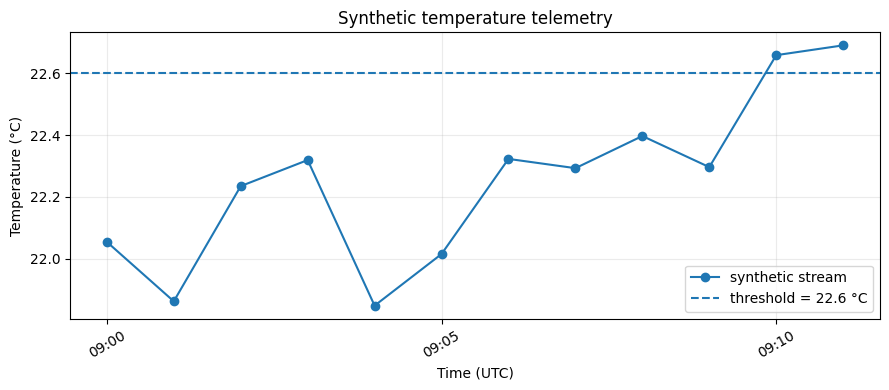

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(df['timestamp'], df['temperature_C'], marker='o', label='synthetic stream')
ax.axhline(threshold, linestyle='--', label=f'threshold = {threshold} °C')
ax.set_xlabel('Time (UTC)')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Synthetic temperature telemetry')
ax.set_xticks(df['timestamp'].iloc[[0, 5, 10]])
ax.set_xticklabels(df['timestamp'].dt.strftime('%H:%M').iloc[[0, 5, 10]])
ax.legend()
ax.grid(True, alpha=0.25)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Modify → rerun → interpret
1. Change `threshold` from `22.6` to `22.3` and rerun only the table and plot cells.
2. Change the random seed from `42` to `7` and rerun Exercise 1.2 and Exercise 1.3.
3. Explain which change altered the **data** and which changed only the **decision rule**.

With seed 42 and a 22.6 °C threshold, two of the twelve samples exceed the threshold. That fact is a result of this synthetic example, not a general property of temperature sensors.

## Clean-run check
Restart the runtime and run all cells from top to bottom. If the table and plot are regenerated without relying on hidden state, the notebook passes the first reproducibility check used throughout this book.

## Practice summary
You have used Markdown and code cells, variables, strings, lists, a function, NumPy arrays, a pandas table, and a Matplotlib plot. More importantly, you have followed the workflow that later notebooks assume.